# Postprocess Mixing & Weighted Plots


This notebook loads postprocessed CMS Flow Matching outputs, computes HS/MB mixing
weights, builds a weighted synthetic sample, and reproduces the event/jet/particle
histograms produced in the original `plot_postprocess.ipynb`.

Steps:
1. Point the configuration block to the postprocessed ROOT files you want to analyse.
2. Run the helper cells to load each dataset, compute weights, and build the weighted mix.
3. Execute the plotting cells to compare the components, the weighted mix, and (optionally) a validation sample.


In [1]:

%load_ext autoreload
%autoreload 2


In [2]:


from parnassus_core.experiments.cms_2011.performance.performance import (
    CMS2011Performance,
    CMS2011PlotHelper,
    CMS2011Sample,
    CMS2011PerformanceConfig,
)



In [3]:
config_dict = {
    "samples": {
        "ttbar": [
            {
                "name": "parnassus",
                "path": "2024_minbias_noPU_noPtCut_800k_postprocess_619k_test_eta30Eval.root",
                "pflow_type": "fm",
                "label": "Parnassus (FM)",
            },
        ]
    }
}


In [4]:


config = CMS2011PerformanceConfig.from_dict(config_dict)



In [5]:


perf = CMS2011Performance(config)



In [6]:


config.sample_dict.keys()



dict_keys([<CMS2011Sample.TTBAR: 'ttbar'>])

In [7]:


perf.load()



Loading data for parnassus from 2024_minbias_noPU_noPtCut_800k_postprocess_619k_test_eta30Eval.root


In [8]:


perf.sample_data_dict[CMS2011Sample.TTBAR].filter_events()



Filtering events for PF with source Source.PF
Data(name=PF, source=Source.PF), events filtered: 619240
Filtering events for TR with source Source.TR
Data(name=TR, source=Source.TR), events filtered: 619240
Filtering events for parnassus with source Source.FM
Data(name=parnassus, source=Source.FM), events filtered: 619240


In [9]:


perf.sample_data_dict[CMS2011Sample.TTBAR].data_dict["PF"]["particle/jet/pt"]



array([array([], dtype=float64), array([], dtype=float64),
       array([], dtype=float64), ..., array([], dtype=float64),
       array([], dtype=float64), array([], dtype=float64)], dtype=object)

In [10]:

perf.sample_data_dict[CMS2011Sample.TTBAR].data_dict["PF"].particle_data_jet["pt"][1310]


array([], dtype=float64)

In [11]:
perf.sample_data_dict[CMS2011Sample.TTBAR].process_data()


Calculating event data for PF with source Source.PF
Calculating event data for TR with source Source.TR
Calculating event data for parnassus with source Source.FM
Processing data for PF with source Source.PF
Calculating event residuals for PF with source Source.PF against TR with source Source.TR
Matching jets for PF with source Source.PF against TR with source Source.TR


Matching jets: 100%|██████████| 619240/619240 [00:20<00:00, 30640.46it/s]


Calculating jet residuals for PF with source Source.PF against TR with source Source.TR


residuals: 100%|██████████| 619240/619240 [00:00<00:00, 3276428.80it/s]


Calculating particle residuals for PF with source Source.PF against TR with source Source.TR
Split:  all


...

Split:  jet


residuals: 100%|██████████| 619240/619240 [00:00<00:00, 2030928.08it/s]


Split:  bkg


residuals: 100%|██████████| 619240/619240 [00:15<00:00, 39334.90it/s]


Calculating impact parameters for parnassus with source Source.FM
No impact parameters found in parnassus for split all. Skipping.
No impact parameters found in parnassus for split jet. Skipping.
No impact parameters found in parnassus for split bkg. Skipping.
Processed data for sample TTBAR


In [12]:

perf.process()


Processing sample: TTBAR
Skipping filter_events: events already filtered
Skipping calculate_event_data: event data already calculated
Skipping calculate_event_data: event data already calculated
Skipping calculate_event_data: event data already calculated
Processing data for PF with source Source.PF
Skipping calculate_event_residuals: event residuals already calculated
Skipping match_jets: jets already matched
Skipping calculate_jet_residuals: jet residuals already calculated
Skipping calculate_particle_residuals: particle residuals already calculated
Skipping calculate_impact_parameters: impact parameters already calculated
Processing data for parnassus with source Source.FM
Skipping calculate_event_residuals: event residuals already calculated
Skipping match_jets: jets already matched
Skipping calculate_jet_residuals: jet residuals already calculated
Skipping calculate_particle_residuals: particle residuals already calculated
Skipping calculate_impact_parameters: impact parameters al

In [13]:


style_dict = {
    "PF": {
        "linewidth": 2,
        "color": "#1f77b4",
        "alpha": 0.3,
    },
    "TR": {
        "linewidth": 2,
        "color": "black",
        "alpha": 1,
    },
    "parnassus": {
        "linewidth": 2,
        "color": "crimson",
    },
}



In [14]:


plot_helper = CMS2011PlotHelper(
    perf, plot_truth=False, style_dict=style_dict, font_size=25
)



In [15]:
import os

OUTDIR = "minbias_600k_training_plots"
os.makedirs(OUTDIR, exist_ok=True)

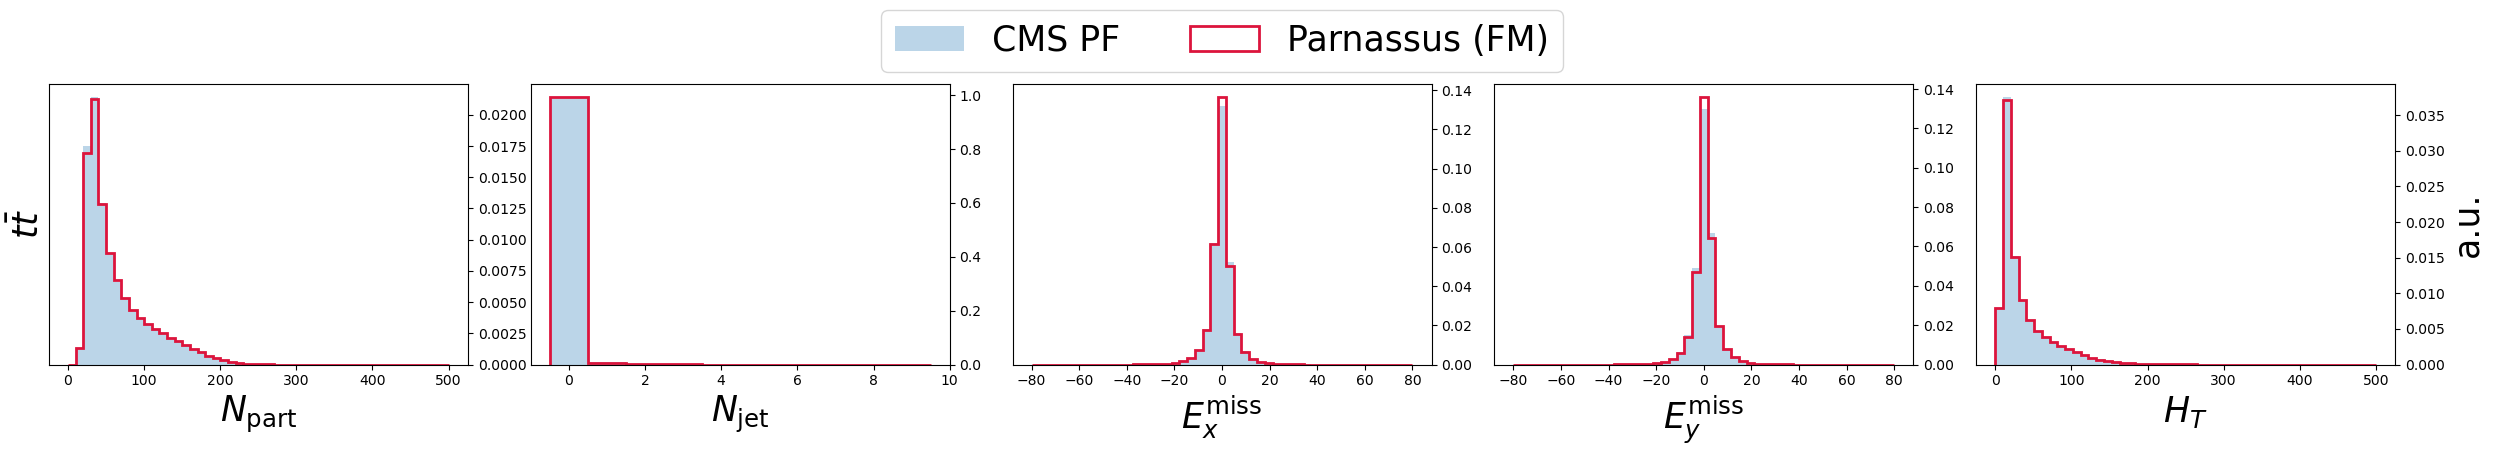

In [16]:
fig = plot_helper.plot_event_features(residuals=False)
fig.savefig(os.path.join(OUTDIR, "event_false.png"), dpi=150, bbox_inches="tight")

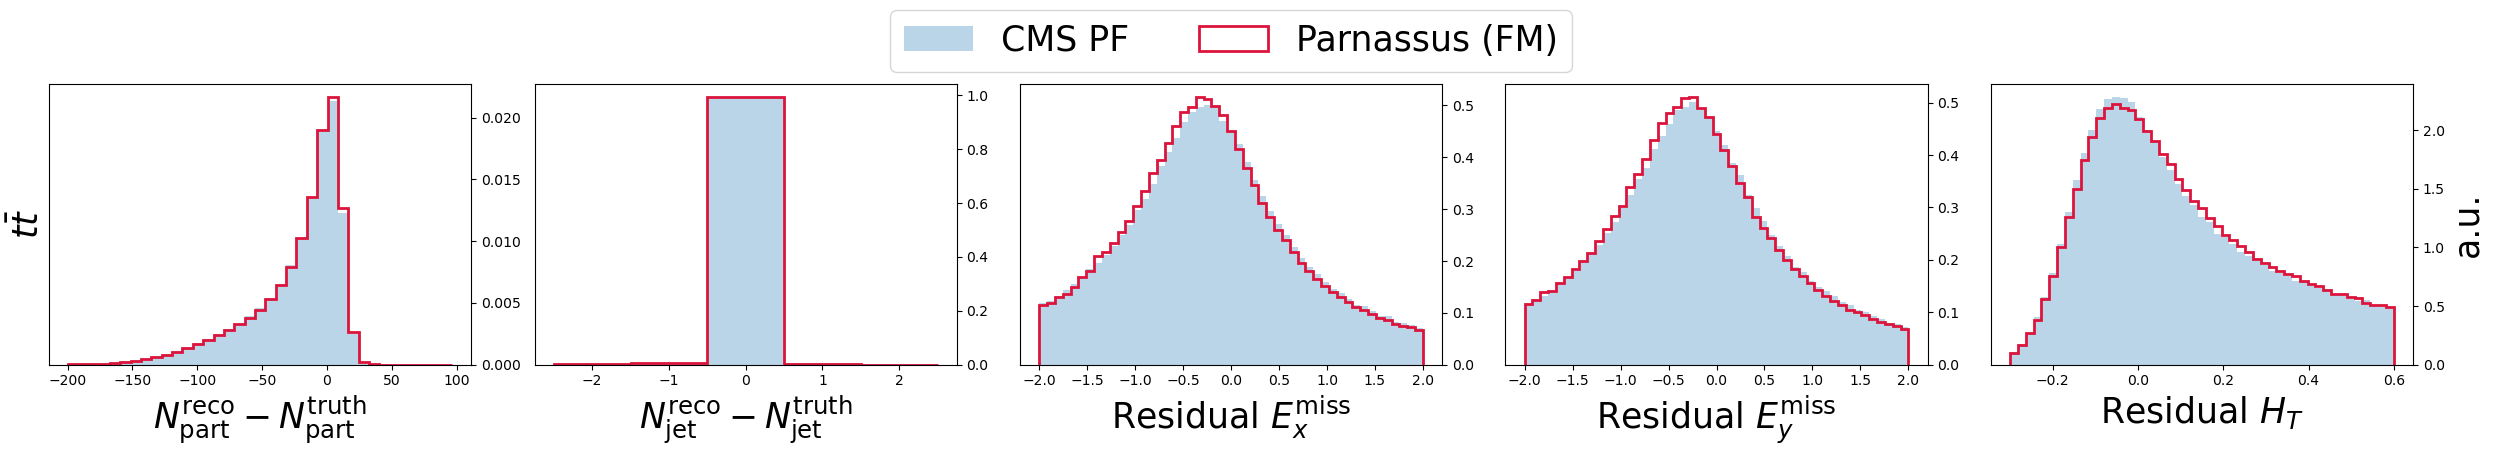

In [17]:
fig = plot_helper.plot_event_features(residuals=True)
fig.savefig(os.path.join(OUTDIR, "event_true.png"), dpi=150, bbox_inches="tight")

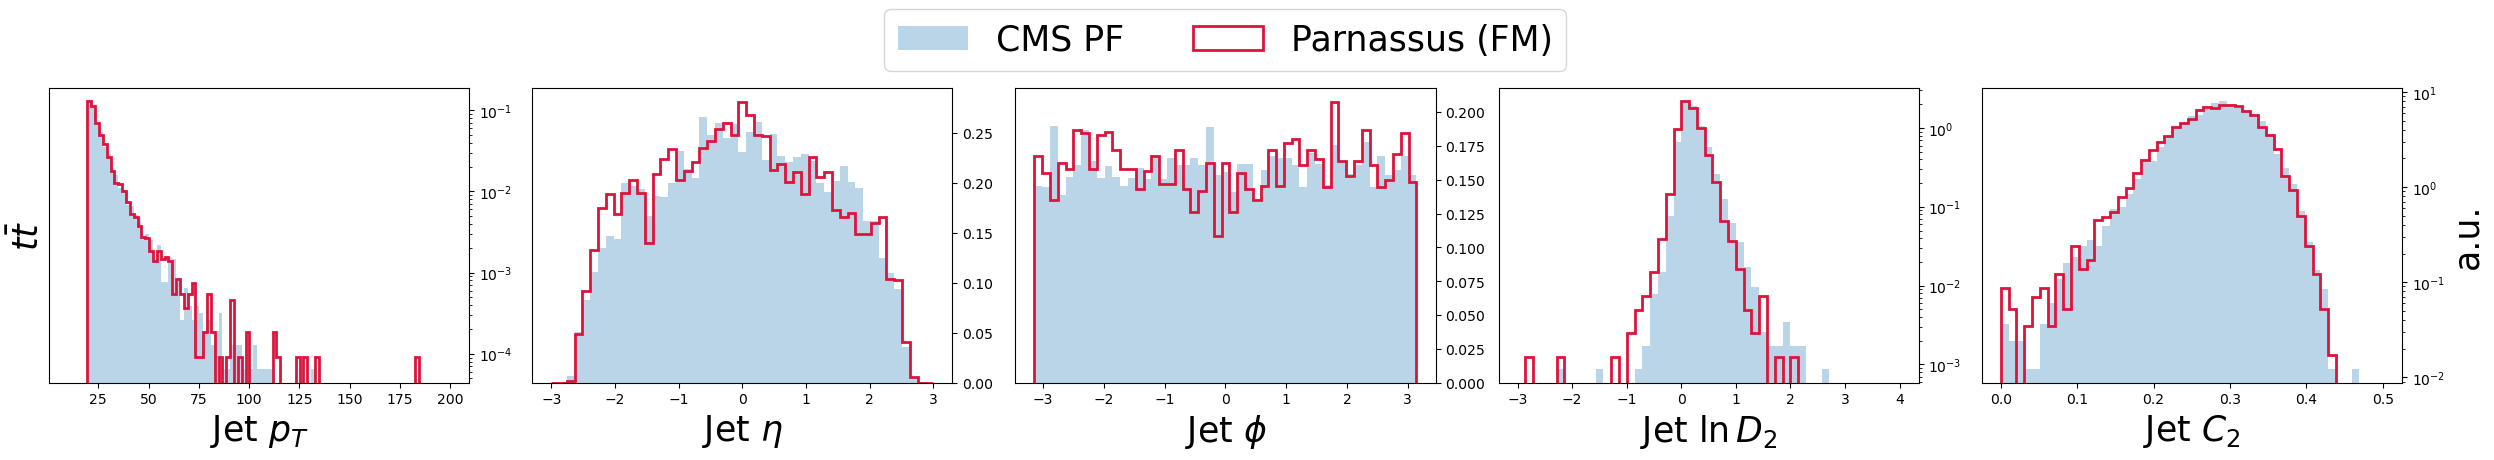

In [18]:
fig = plot_helper.plot_jet_features(log_scale_vars=["pt", "d2", "c2"])
fig.savefig(os.path.join(OUTDIR, "jet_false.png"), dpi=150, bbox_inches="tight")

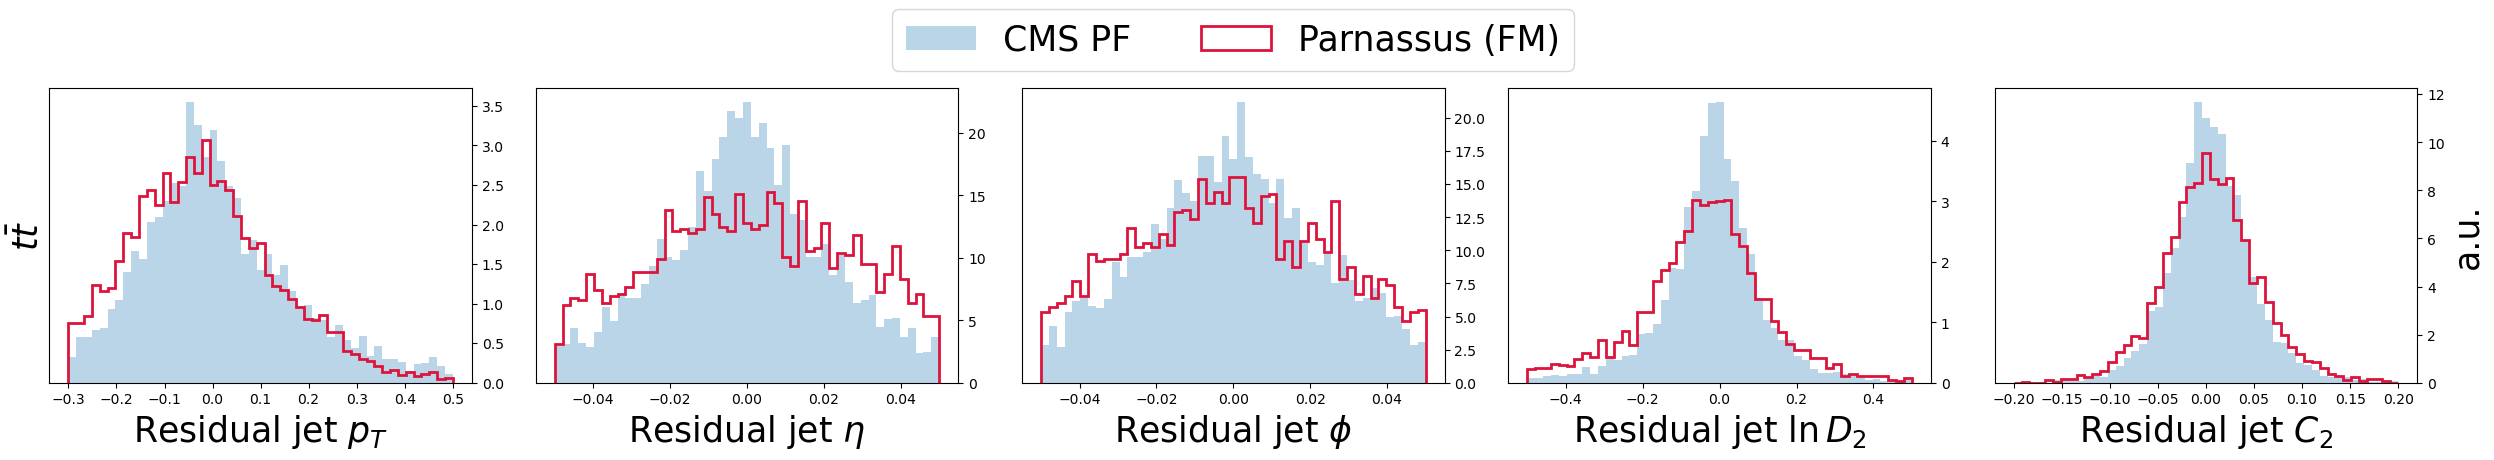

In [19]:
fig = plot_helper.plot_jet_features(residuals=True)
fig.savefig(os.path.join(OUTDIR, "jet_true.png"), dpi=150, bbox_inches="tight")

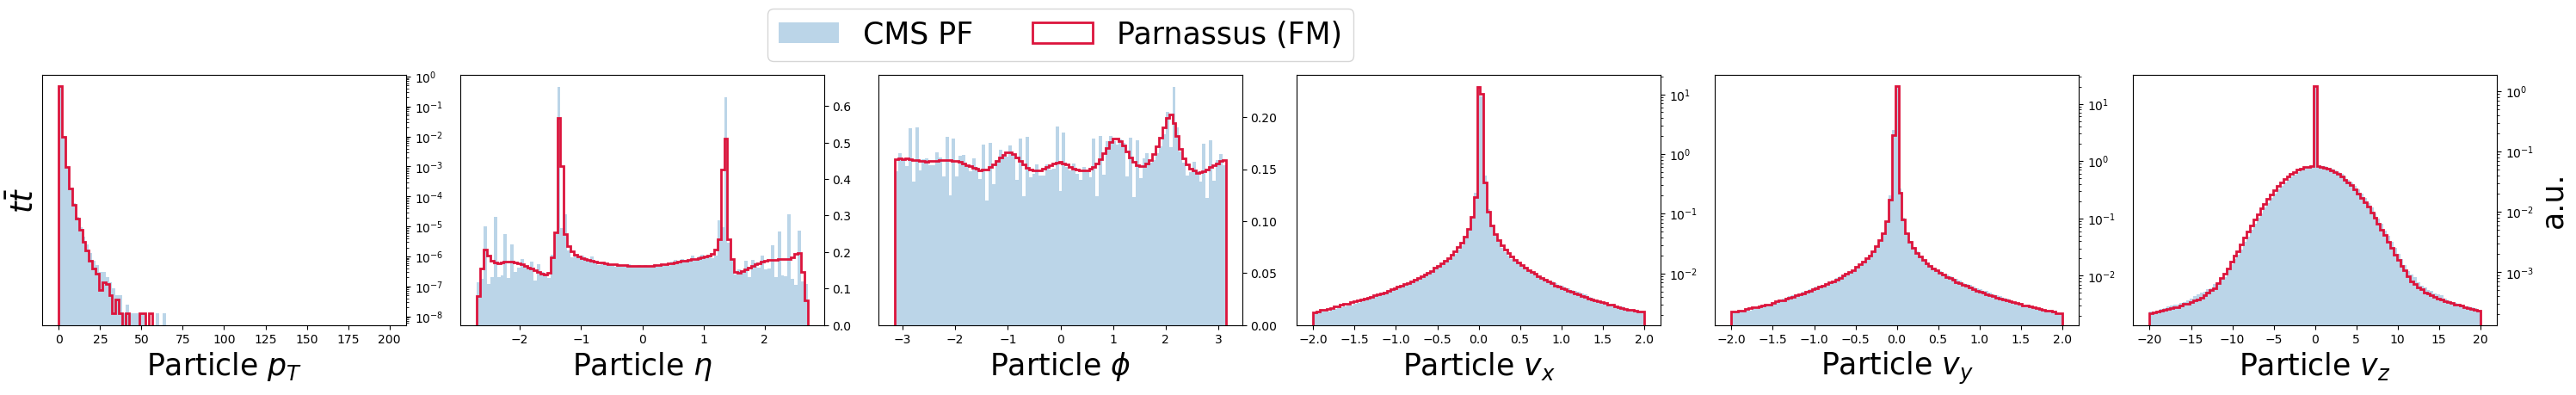

In [20]:
fig = plot_helper.plot_particle_features(log_scale_vars=["pt", "vx", "vy", "vz"])
fig.savefig(os.path.join(OUTDIR, "part_false.png"), dpi=150, bbox_inches="tight")

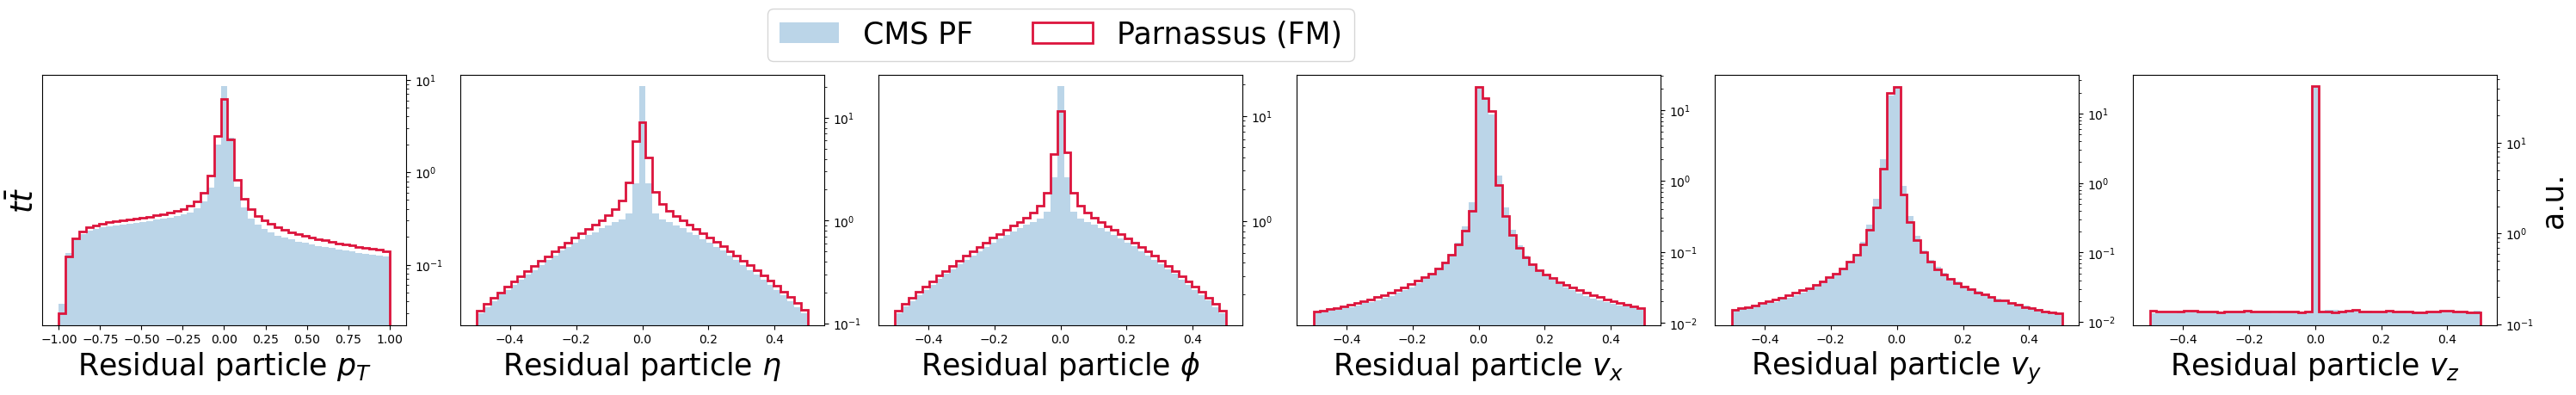

In [21]:
fig = plot_helper.plot_particle_features(residuals=True, log_scale_vars="all")
fig.savefig(os.path.join(OUTDIR, "part_true.png"), dpi=150, bbox_inches="tight")